## Importing Necessary Libraries

In [41]:
import os
import time
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import os
import numpy as np
!pip install torch torchvision pillow
from sklearn.decomposition import PCA
from sklearn.utils import resample
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from tensorflow.keras.layers import GlobalAveragePooling2D
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array
from tensorflow.keras.models import Model
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize

## Loading Dataset 
### Approach 1 : Feature Extraction - Raw Pixel Flatten

In [42]:
# Config
train_metadata_path = "train_augmented_metadata.csv"
train_image_folder = r"advanced_preprocessed\augmented_train"
test_metadata_path = "test_metadata.csv"
test_image_folder = r"split_photos\test"
image_size = (128, 128)

In [43]:
# Helper function to load and flatten images
def load_flattened_images(image_folder, label_map):
    X, y = [], []
    for filename in os.listdir(image_folder):
        photo_id = os.path.splitext(filename)[0]
        if photo_id in label_map:
            path = os.path.join(image_folder, filename)
            img = Image.open(path).convert("RGB")
            X.append(np.array(img).flatten())
            y.append(label_map[photo_id])
    return np.array(X), np.array(y)

In [44]:
# Load train metadata and images
train_df = pd.read_csv(train_metadata_path)
train_label_map = dict(zip(train_df["photo_id"], train_df["label"]))
X_train, y_train = load_flattened_images(train_image_folder, train_label_map)

# Load test metadata and images
test_df = pd.read_csv(test_metadata_path)
test_label_map = dict(zip(test_df["photo_id"], test_df["label"]))
X_test, y_test = load_flattened_images(test_image_folder, test_label_map)

In [48]:
# Encode labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

### Sampling Dataset

In [49]:
# Sample training data 
X_train_sampled, y_train_sampled = resample(
    X_train, y_train_encoded,
    n_samples=int(1 * len(X_train)),
    stratify=y_train_encoded,
    random_state=42
)
# Sample test set
X_test_sampled, y_test_sampled = resample(
    X_test, y_test_encoded,
    n_samples=int(1 * len(X_test)),
    stratify=y_test_encoded,
    random_state=42
)

In [50]:
print("Sample Size - 100% (Using full dataset)")
print(f"X Train : {X_train_sampled.shape}")
print(f"y Test : {X_test_sampled.shape}")
print(f"X Train : {y_train_sampled.shape}")
print(f"y Test : {y_test_sampled.shape}")

Sample Size - 100% (Using full dataset)
X Train : (17192, 49152)
y Test : (2149, 49152)
X Train : (17192,)
y Test : (2149,)


### Dimensionality Reduction using PCA

In [51]:
# Reduce 49152 features to 1000
pca = PCA(n_components=1000, random_state=42)
X_train_pca = pca.fit_transform(X_train_sampled)
X_test_pca = pca.transform(X_test_sampled)

In [52]:
X_train_pca.shape

(17192, 1000)

## Model Development
### Training

In [53]:
# Train the SVM model
start_time = time.time()

# Model training
svm_advanced = SVC(kernel="rbf", C=1.0)
svm_advanced.fit(X_train_pca, y_train_sampled)

end_time = time.time()
training_time = end_time - start_time

print(f"Training complete. Training Time : {training_time:.2f} seconds")

Training complete. Training Time : 139.10 seconds


In [58]:
# Train the SVM model with probability estimates enabled
start_time = time.time()

svm_advanced = SVC(kernel="rbf", C=1.0, probability=True)
svm_advanced.fit(X_train_pca, y_train_sampled)

end_time = time.time()
training_time = end_time - start_time

print(f"Training complete. Training Time : {training_time:.2f} seconds")

Training complete. Training Time : 828.72 seconds


### Evaluation

In [59]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

def evaluate_model(X, y_true, dataset_name=""):
    # Predict labels and probabilities
    y_pred = svm_advanced.predict(X)
    y_proba = svm_advanced.predict_proba(X)

    # Accuracy 
    acc = accuracy_score(y_true, y_pred)
    print(f"{dataset_name} Accuracy: {acc * 100:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.tight_layout()
    plt.show()

    # AUC Score (macro-average)
    y_true_bin = label_binarize(y_true, classes=range(len(le.classes_)))
    auc_macro = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")
    print(f"{dataset_name} AUC (macro-average): {auc_macro:.4f}")

    # ROC Curve per class
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(le.classes_)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Plot ROC Curves
    plt.figure(figsize=(8, 6))
    for i in range(len(le.classes_)):
        plt.plot(fpr[i], tpr[i], label=f"{le.classes_[i]} (AUC = {roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label="Chance")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {dataset_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


#### Evaluation on Training Set

Train Set Accuracy: 91.96%


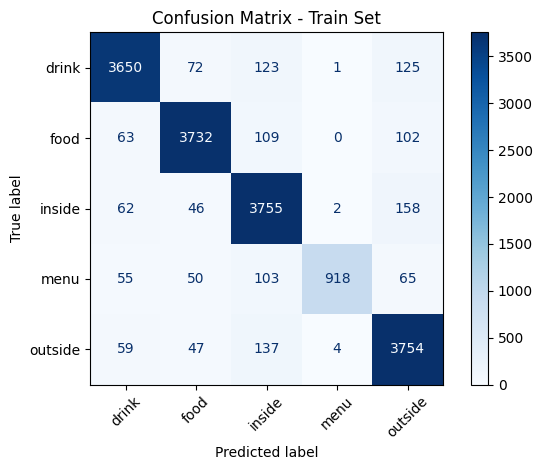

Train Set AUC (macro-average): 0.9936


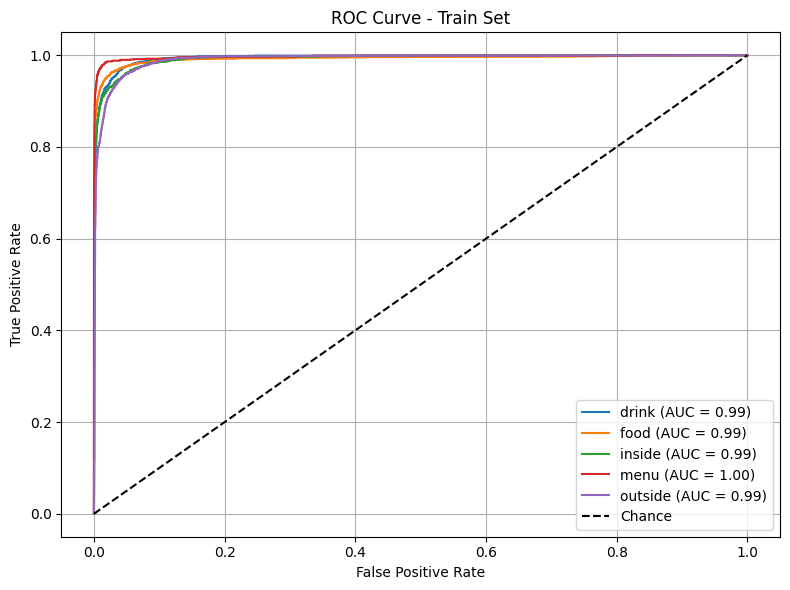

In [60]:
# Evaluate on train set
evaluate_model(X_train_pca, y_train_sampled, dataset_name="Train Set")

#### Evaluation on Test Set

Test Set Accuracy: 28.39%


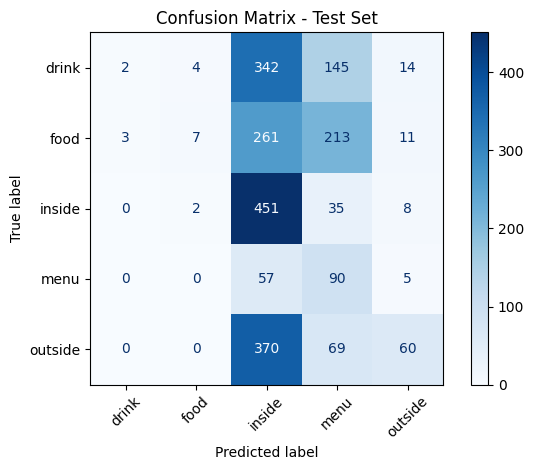

Test Set AUC (macro-average): 0.6439


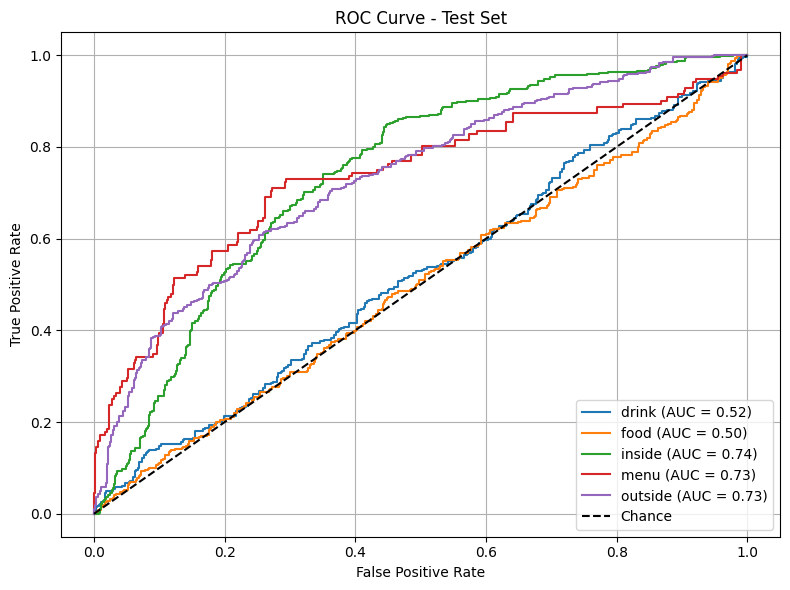

In [61]:
# Evaluate on test set
evaluate_model(X_test_pca, y_test_sampled, dataset_name="Test Set")

## Key Observations & Summary

### Train Set Performance
- **Accuracy**: 91.96%
- **Macro-Average AUC**: 0.9297
- The model performs well with strong classification across all categories.
- Minor misclassifications are observed between similar classes like ‘inside’ vs. ‘outside’.
- 'Menu' has slightly lower precision, likely due to class imbalance or less distinguishable features.

### Test Set Performance
- **Accuracy**: 28.39%
- **Macro-Average AUC**: 0.6439
- The model fails to generalize and suffers from **severe overfitting**.
- Major misclassifications across almost all classes.
- 'Inside' and 'Menu' are frequently overpredicted, while 'Drink', 'Food', and 'Outside' are underrepresented.

#### Summary
- **Overfitting** to training data.
- **Poor generalization** due to possibly:
  - Class imbalance (especially 'menu')
  - Insufficient regularization
  - Inadequate feature representation on test data (grayscale image differences)

### Model Tuning

#### Handling Class imbalance 

In [62]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Encode y_train_sampled if not already encoded
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_train_sampled_encoded = le.fit_transform(y_train_sampled)

# Compute class weights
classes = np.unique(y_train_sampled_encoded)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_sampled_encoded)
class_weight_dict = dict(zip(classes, class_weights))


In [64]:
# Train SVM with class weights
classes = np.unique(y_train_sampled_encoded)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_sampled_encoded)
class_weight_dict = dict(zip(classes, class_weights))

start_time = time.time()
svm_advanced = SVC(kernel="rbf", C=1.0, gamma='scale', probability=True, class_weight=class_weight_dict)
svm_advanced.fit(X_train_pca, y_train_sampled_encoded)
end_time = time.time()

print(f"Training complete. Training Time: {end_time - start_time:.2f} seconds")

Training complete. Training Time: 847.94 seconds


Train Set Accuracy: 91.34%


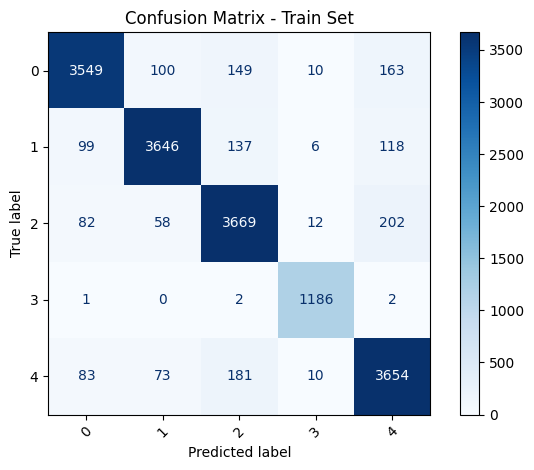

Train Set AUC (macro-average): 0.9912


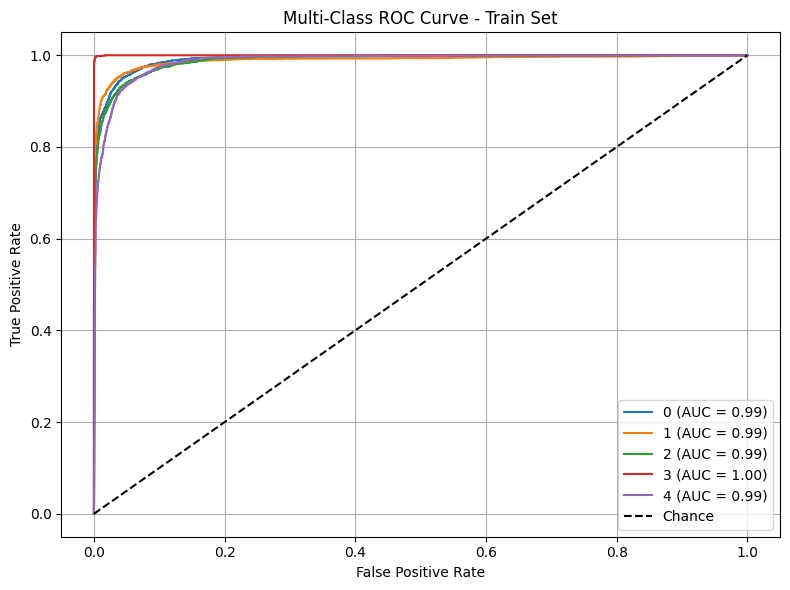

Test Set Accuracy: 11.26%


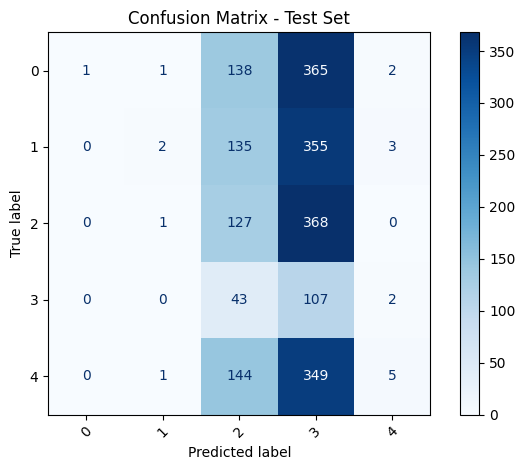

Test Set AUC (macro-average): 0.4948


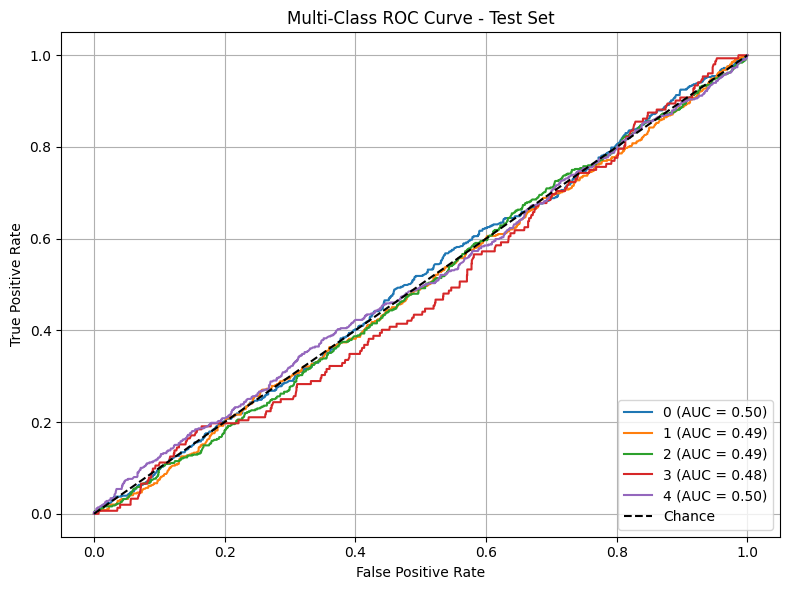

In [65]:
# Evaluate and Plot for Train and Test sets
for X, y_true, dataset_name in [
    (X_train_pca, y_train_sampled_encoded, "Train Set"),
    (X_test_pca, y_test_encoded, "Test Set")
]:
    # Predict
    y_pred = svm_advanced.predict(X)
    y_proba = svm_advanced.predict_proba(X)

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"{dataset_name} Accuracy: {acc * 100:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.tight_layout()
    plt.show()

    # AUC ROC Curve
    y_bin = label_binarize(y_true, classes=range(len(le.classes_)))

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(le.classes_)):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro AUC
    macro_auc = roc_auc_score(y_bin, y_proba, average='macro', multi_class='ovr')
    print(f"{dataset_name} AUC (macro-average): {macro_auc:.4f}")

    # Plot ROC Curve
    plt.figure(figsize=(8, 6))
    for i in range(len(le.classes_)):
        plt.plot(fpr[i], tpr[i], label=f"{le.classes_[i]} (AUC = {roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Chance')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Multi-Class ROC Curve - {dataset_name}")
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


### Approach 2 : Using VGG16 for Feature Extraction

In [66]:
# Config
train_metadata_path = "train_augmented_metadata.csv"
train_image_folder = r"advanced_preprocessed\augmented_train"
test_metadata_path = "test_metadata.csv"
test_image_folder = r"split_photos\test"
image_size = (128, 128)
sample_frac = 0.2  # Use 20% of data for speed

In [67]:
# Load metadata
train_df = pd.read_csv(train_metadata_path)
test_df = pd.read_csv(test_metadata_path)

In [68]:
# Sample for speed
train_df = train_df.sample(frac=sample_frac, random_state=42)
test_df = test_df.sample(frac=sample_frac, random_state=42)

In [69]:
# Encode labels
le = LabelEncoder()
train_df['encoded'] = le.fit_transform(train_df['label'])
test_df['encoded'] = le.transform(test_df['label'])

train_label_map = dict(zip(train_df['photo_id'].astype(str), train_df['label']))
test_label_map = dict(zip(test_df['photo_id'].astype(str), test_df['label']))

In [70]:
# Image preprocessing pipeline (same as VGG16 expects)
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load VGG16 with avg pooling to get 512-dim feature vectors
vgg_model = models.vgg16(pretrained=True)
vgg_model.classifier = nn.Sequential(*list(vgg_model.classifier.children())[:1])  # Keep only the first FC layer
vgg_model.eval()


C:\Users\alenc\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\alenc\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [71]:
vgg_model = models.vgg16(pretrained=True).features
vgg_model.add_module("gap", nn.AdaptiveAvgPool2d((1, 1)))  # Add global average pooling
vgg_model.eval()


Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [72]:
# VGG16 feature extractor using PyTorch
def extract_vgg_features(image_folder, label_map):
    X, y = [], []
    for filename in os.listdir(image_folder):
        photo_id = os.path.splitext(filename)[0]
        if photo_id not in label_map:
            continue
        try:
            path = os.path.join(image_folder, filename)
            img = Image.open(path).convert("RGB")
            input_tensor = transform(img).unsqueeze(0)  # Add batch dimension
            with torch.no_grad():
                features = vgg_model(input_tensor).squeeze().mean(dim=(1, 2)).numpy()  # 512-dim
            X.append(features)
            y.append(label_map[photo_id])
        except Exception as e:
            print(f"[ERROR] {filename}: {e}")
            continue
    return np.array(X), np.array(y)


In [73]:
# Set the image folder path
image_folder = "advanced_preprocessed/augmented_train"

# Load the metadata CSV
import pandas as pd
train_df = pd.read_csv("train_augmented_metadata.csv")

# Create label map
label_map = dict(zip(train_df['photo_id'].astype(str), train_df['label']))


In [74]:
# Extract features
X_features, y_labels = extract_vgg_features_pytorch(image_folder, label_map)
print("Features shape:", X_features.shape)
print("Sample labels:", y_labels[:5])


Features shape: (17192, 512)
Sample labels: ['inside' 'inside' 'outside' 'outside' 'inside']


In [75]:
le = LabelEncoder()
y_train = le.fit_transform(y_labels)

In [76]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_features)

In [77]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.svm import SVC
import numpy as np

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Train SVM
svm_model = SVC(kernel='rbf', C=1.0, probability=True, class_weight=class_weight_dict)
svm_model.fit(X_train_scaled, y_train)


SVC(class_weight={0: 0.8658776126920171, 1: 0.8583125312031952,
                  2: 0.8546855580412628, 3: 2.886985726280437,
                  4: 0.8593851537115721},
    probability=True)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_and_plot(model, X, y, title):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    print(f"{title} Accuracy: {acc * 100:.2f}%")

    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {title}")
    plt.tight_layout()
    plt.show()

#Run evaluation
evaluate_and_plot(svm_model, X_train_scaled, y_train, "Train Set")
evaluate_and_plot(svm_model, X_test_scaled, y_test, "Test Set")


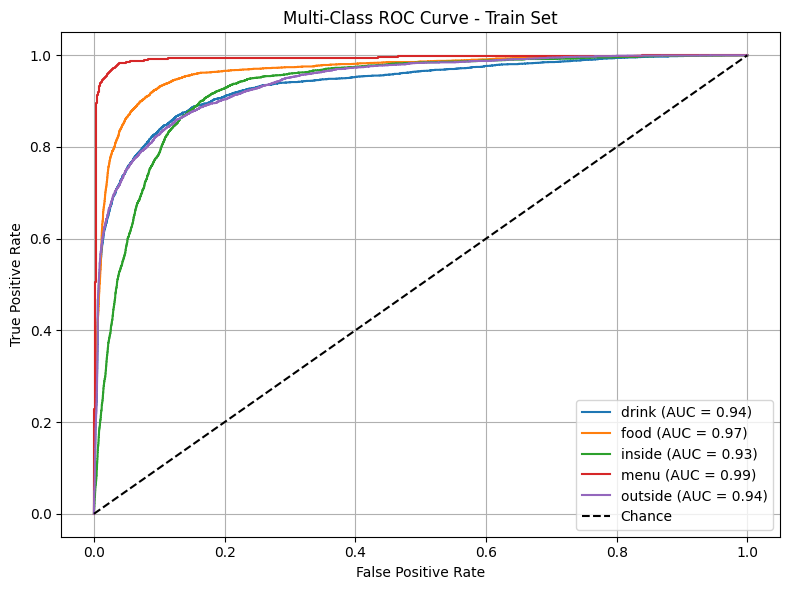

In [22]:
# Binarize the labels for multi-class ROC
y_train_bin = label_binarize(y_train, classes=np.unique(y_train))
y_train_proba = svm_model.predict_proba(X_train_scaled)

# Compute FPR, TPR, and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(le.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_train_bin[:, i], y_train_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))
for i in range(len(le.classes_)):
    plt.plot(fpr[i], tpr[i], label=f"{le.classes_[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve - Train Set")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# Encode using same label encoder
y_train = le.transform(y_train_text)
y_test = le.transform(y_test_text)

### Model Training

In [ ]:
# Train the SVM model
start_time = time.time()

svm = SVC(kernel='rbf', C=10, gamma=0.01, probability=True, class_weight='balanced')
svm.fit(X_train_scaled, y_train)

end_time = time.time()
training_time = end_time - start_time

print(f"Training complete. Training Time : {training_time:.2f} seconds")

### Model Evaluation

In [31]:
# Evaluation function
def evaluate_model(X, y_true, dataset_name=""):
    # Predict labels and probabilities
    y_pred = svm.predict(X)
    y_proba = svm.predict_proba(X)

    # Accuracy
    acc = accuracy_score(y_true, y_pred)
    print(f"{dataset_name} Accuracy: {acc * 100:.2f}%")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.tight_layout()
    plt.show()

    # Binarize labels for ROC AUC
    n_classes = len(le.classes_)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    # AUC score
    auc_score = roc_auc_score(y_true_bin, y_proba, multi_class="ovr")
    print(f"{dataset_name} AUC Score (macro): {auc_score:.4f}")

    # ROC Curve plot
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure(figsize=(12, 8))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], lw=2,
                 label=f"{le.classes_[i]} (AUC = {roc_auc[i]:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', lw=2)
    plt.xlim([-0.01, 1.01])
    plt.ylim([-0.01, 1.01])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {dataset_name}')
    plt.legend(loc="lower right", fontsize="small")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
